Using Colab cache for faster access to the 'student-performance-prediction' dataset.
Dataset Path: /kaggle/input/student-performance-prediction
['student_performance_dataset.csv']
  Student_ID  Gender  Study_Hours_per_Week  Attendance_Rate  Past_Exam_Scores  \
0       S147    Male                    31        68.267841                86   
1       S136    Male                    16        78.222927                73   
2       S209  Female                    21        87.525096                74   
3       S458  Female                    27        92.076483                99   
4       S078  Female                    37        98.655517                63   

  Parental_Education_Level Internet_Access_at_Home Extracurricular_Activities  \
0              High School                     Yes                        Yes   
1                      PhD                      No                         No   
2                      PhD                     Yes                         No   
3        

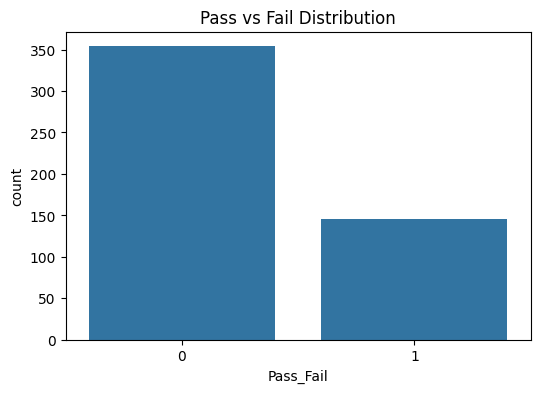

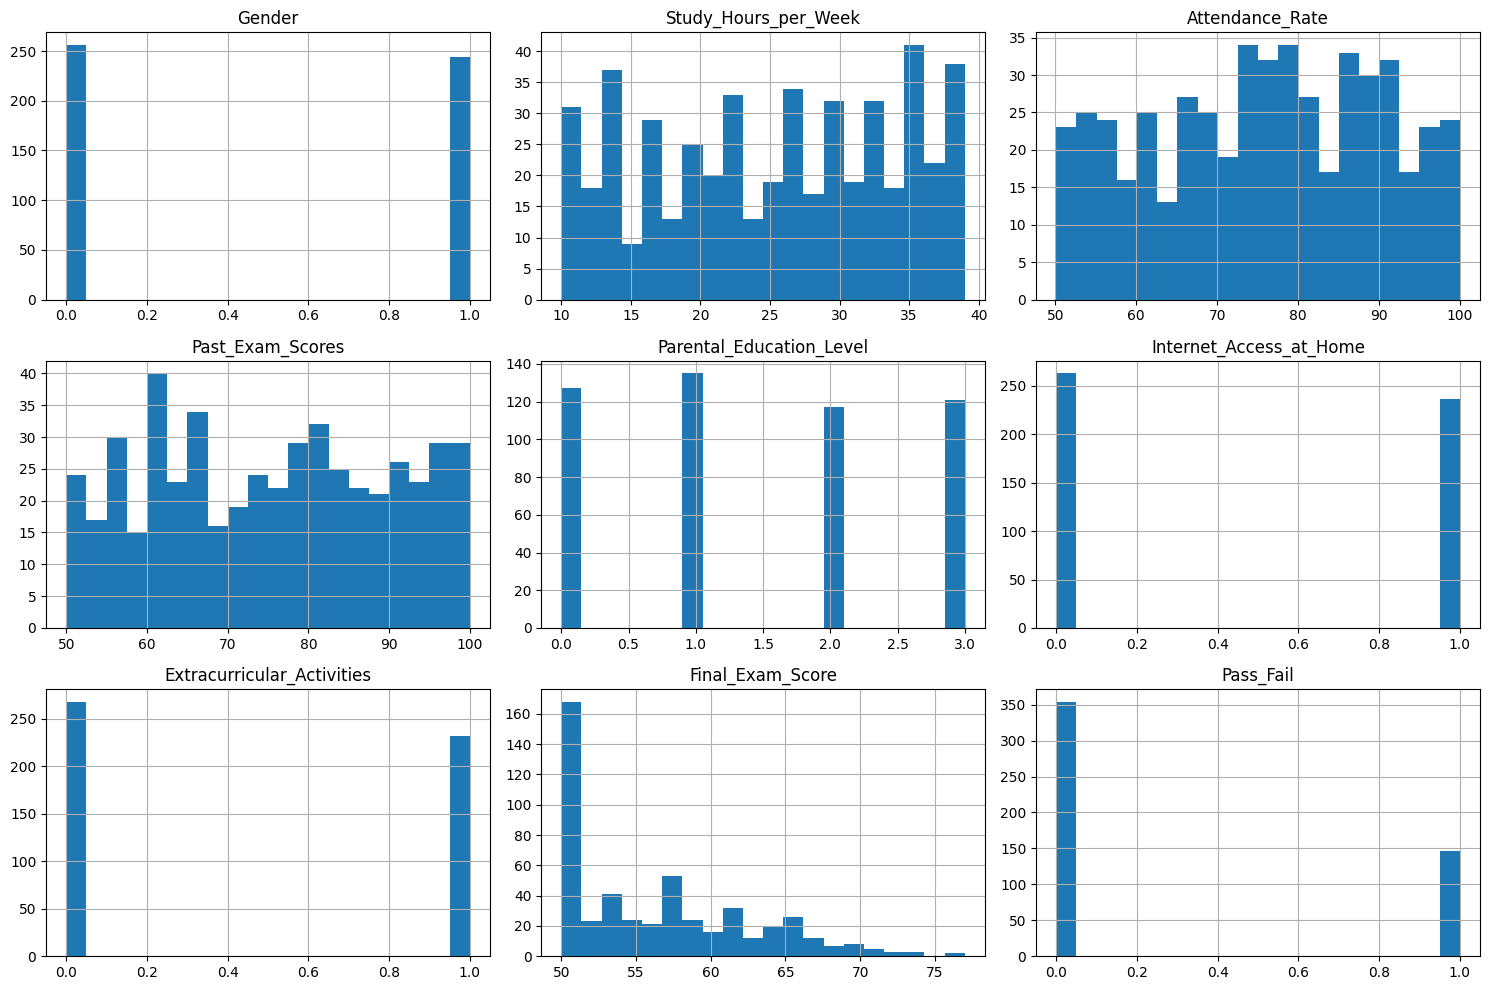

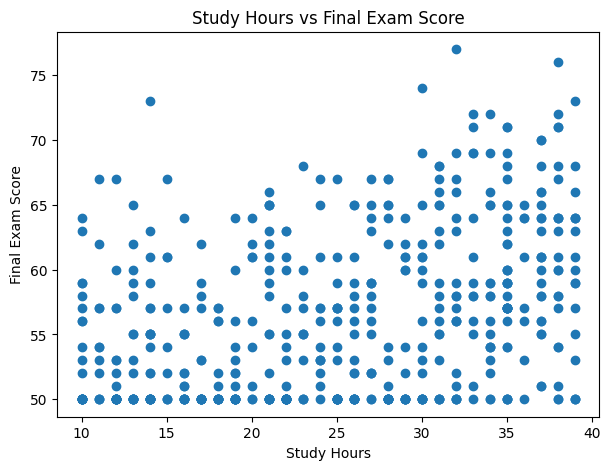

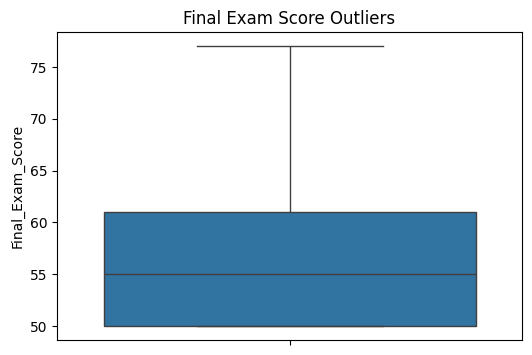

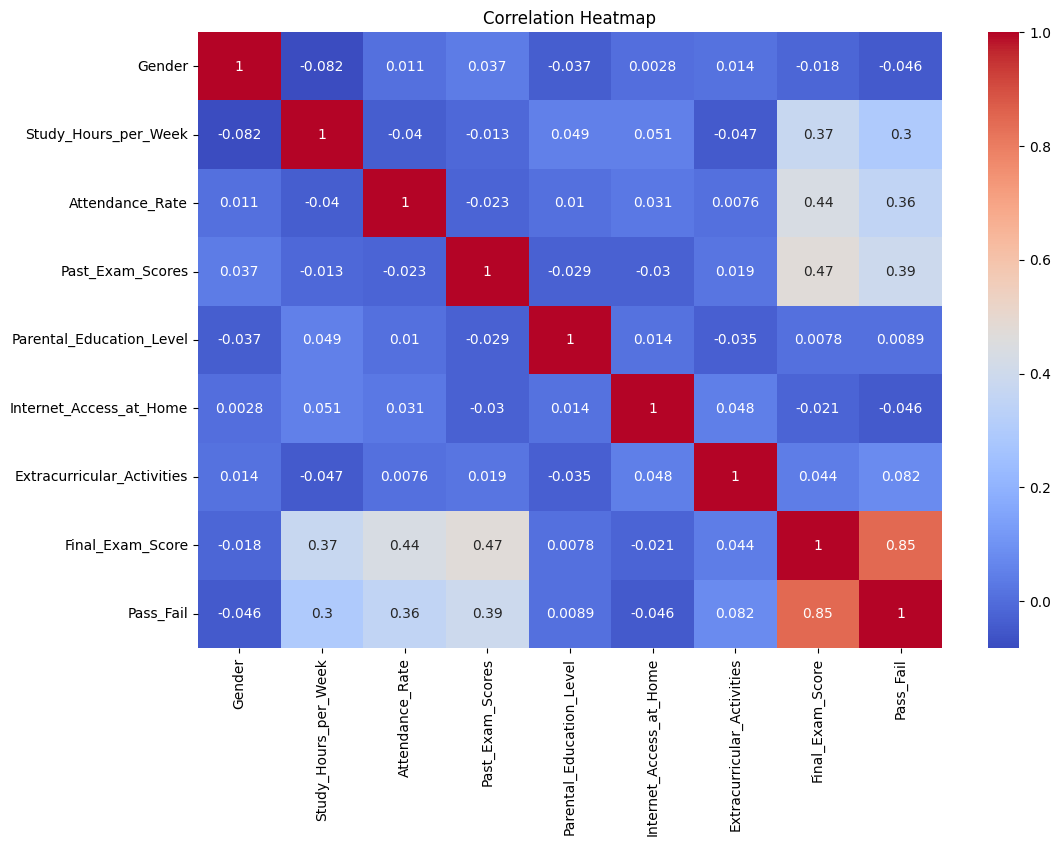

Risk_Category
Low Risk       269
Medium Risk    231
Name: count, dtype: int64

Accuracy Score
0.99

Precision
1.0

Recall
0.96

F1 Score
0.9795918367346939

ROC AUC
1.0

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        75
           1       1.00      0.96      0.98        25

    accuracy                           0.99       100
   macro avg       0.99      0.98      0.99       100
weighted avg       0.99      0.99      0.99       100



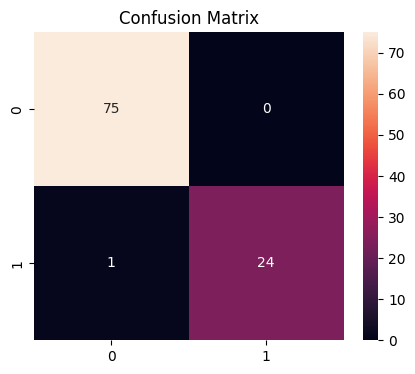


PROJECT COMPLETED SUCCESSFULLY


In [1]:
# ============================================================
# STUDENT EXAM PASS PREDICTION SYSTEM
# EDA + LOGISTIC REGRESSION + PLOTLY DASHBOARD
# ============================================================

# ==========================
# 1. Import Libraries
# ==========================
import kagglehub
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)

# ==========================
# 2. Download Dataset
# ==========================
path = kagglehub.dataset_download(
    "amrmaree/student-performance-prediction"
)

print("Dataset Path:", path)

# Check files
print(os.listdir(path))

# ==========================
# 3. Load Dataset
# ==========================
csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]

df = pd.read_csv(os.path.join(path, csv_file))

print(df.head())
print(df.shape)

# ==========================
# 4. Dataset Information
# ==========================
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Records")
print(df.duplicated().sum())

# Remove Duplicates
df = df.drop_duplicates()

# ==========================
# 5. Descriptive Statistics
# ==========================
print(df.describe())

# ==========================
# 6. Pass / Fail Creation
# ==========================
if "Pass_Fail" not in df.columns:

    if "Final_Exam_Score" in df.columns:
        df["Pass_Fail"] = np.where(
            df["Final_Exam_Score"] >= 50,
            "Pass",
            "Fail"
        )

# ==========================
# 7. Encoding
# ==========================
label_encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = label_encoder.fit_transform(df[col])

# ==========================
# 8. Remove Student_ID
# ==========================
if "Student_ID" in df.columns:
    df = df.drop("Student_ID", axis=1)

# ==========================
# 9. Basic Statistics
# ==========================
print("Average Study Hours")

if "Study_Hours_per_Week" in df.columns:
    print(df["Study_Hours_per_Week"].mean())

print("Average Attendance")

if "Attendance_Rate" in df.columns:
    print(df["Attendance_Rate"].mean())

print("Average Past Exam Scores")

if "Past_Exam_Scores" in df.columns:
    print(df["Past_Exam_Scores"].mean())

# ==========================
# 10. Pass vs Fail
# ==========================
plt.figure(figsize=(6,4))
sns.countplot(x="Pass_Fail", data=df)
plt.title("Pass vs Fail Distribution")
plt.show()

# ==========================
# 11. Histograms
# ==========================
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

# ==========================
# 12. Scatter Plots
# ==========================
if "Study_Hours_per_Week" in df.columns and "Final_Exam_Score" in df.columns:

    plt.figure(figsize=(7,5))
    plt.scatter(
        df["Study_Hours_per_Week"],
        df["Final_Exam_Score"]
    )

    plt.xlabel("Study Hours")
    plt.ylabel("Final Exam Score")
    plt.title("Study Hours vs Final Exam Score")
    plt.show()

# ==========================
# 13. Box Plot
# ==========================
if "Final_Exam_Score" in df.columns:

    plt.figure(figsize=(6,4))
    sns.boxplot(y=df["Final_Exam_Score"])
    plt.title("Final Exam Score Outliers")
    plt.show()

# ==========================
# 14. Correlation Heatmap
# ==========================
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# ==========================
# 15. Risk Analysis
# ==========================
def risk_category(row):

    if (
        row["Attendance_Rate"] < 60 and
        row["Study_Hours_per_Week"] < 5
    ):
        return "High Risk"

    elif (
        row["Attendance_Rate"] < 75
    ):
        return "Medium Risk"

    else:
        return "Low Risk"

if (
    "Attendance_Rate" in df.columns and
    "Study_Hours_per_Week" in df.columns
):

    df["Risk_Category"] = df.apply(
        risk_category,
        axis=1
    )

    print(df["Risk_Category"].value_counts())

# ==========================
# 16. Logistic Regression
# ==========================
X = df.drop(
    ["Pass_Fail"],
    axis=1
)

if "Risk_Category" in X.columns:
    X = X.drop(
        ["Risk_Category"],
        axis=1
    )

y = df["Pass_Fail"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

# ==========================
# 17. Evaluation
# ==========================
print("\nAccuracy Score")
print(
    accuracy_score(
        y_test,
        y_pred
    )
)

print("\nPrecision")
print(
    precision_score(
        y_test,
        y_pred
    )
)

print("\nRecall")
print(
    recall_score(
        y_test,
        y_pred
    )
)

print("\nF1 Score")
print(
    f1_score(
        y_test,
        y_pred
    )
)

print("\nROC AUC")
print(
    roc_auc_score(
        y_test,
        y_prob
    )
)

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred
    )
)

# ==========================
# 18. Confusion Matrix
# ==========================
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.show()

# ==========================
# 19. Plotly Dashboard
# ==========================

fig1 = px.histogram(
    df,
    x="Pass_Fail",
    title="Pass vs Fail Distribution"
)
fig1.show()

if "Gender" in df.columns:
    fig2 = px.histogram(
        df,
        x="Gender",
        title="Gender Distribution"
    )
    fig2.show()

if "Study_Hours_per_Week" in df.columns:
    fig3 = px.histogram(
        df,
        x="Study_Hours_per_Week",
        title="Study Hours Distribution"
    )
    fig3.show()

if "Attendance_Rate" in df.columns:
    fig4 = px.histogram(
        df,
        x="Attendance_Rate",
        title="Attendance Distribution"
    )
    fig4.show()

if (
    "Study_Hours_per_Week" in df.columns and
    "Final_Exam_Score" in df.columns
):
    fig5 = px.scatter(
        df,
        x="Study_Hours_per_Week",
        y="Final_Exam_Score",
        color="Pass_Fail",
        title="Study Hours vs Final Exam Score"
    )
    fig5.show()

corr = df.corr(numeric_only=True)

fig6 = go.Figure(
    data=go.Heatmap(
        z=corr.values,
        x=corr.columns,
        y=corr.columns
    )
)

fig6.update_layout(
    title="Correlation Heatmap"
)

fig6.show()

print("\nPROJECT COMPLETED SUCCESSFULLY")